# 6. XGBoost + Optuna — Predicting Smartphone Addiction

Última palanca sin explotar del episodio. Todos los modelos anteriores corrieron con **una sola
configuración de hiperparámetros elegida a mano**; acá se busca en serio.

Es lo que queda después de descartar, con evidencia, las otras vías:

| Intento | CV AUC | Correlación de rangos vs XGBoost | ¿Aportó al ensamble? |
|---|---|---|---|
| LightGBM | 0,96422 | 0,9955 | No: +0,00016, por debajo del ruido entre folds |
| Red neuronal | ~0,939 | 0,9603 | No: el blend empeora con cualquier peso |
| TabICL (foundation model) | ~0,94 proyectado | 0,9515 | No, pese a ser el más diverso de los tres |

El patrón fue consistente: **la diversidad creció y la ganancia nunca apareció**, porque la
performance caía más rápido que la correlación. Con eso, tunear el modelo más fuerte es la opción
que queda con expectativa razonable.

**Referencia a batir: `3_xgboost.ipynb` con CV AUC 0,96478** (0,96634 en el leaderboard público).

> **Tiempo de ejecución: ~70-80 minutos** (~50-60 min de búsqueda + ~20 min de la CV final), en CPU.

**Métrica:** ROC AUC · **Dataset:** Playground Series S6E8

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import optuna.visualization.matplotlib as ovm
from scipy.stats import rankdata
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import time
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)
plt.rcParams["figure.dpi"] = 100
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED    = 42
N_FOLDS = 5

print(f"optuna {optuna.__version__}")

optuna 4.7.0


## 1. Carga y Preprocesamiento

In [2]:
train_raw = pd.read_csv("../data/train.csv")
test_raw  = pd.read_csv("../data/test.csv")

TARGET = "addicted_label"

crudas_num = ["age", "daily_screen_time_hours", "weekend_screen_time", "social_media_hours",
              "gaming_hours", "work_study_hours", "sleep_hours", "notifications_per_day",
              "app_opens_per_day"]
crudas_cat = ["gender", "stress_level", "academic_work_impact"]


def agregar_derivadas(df):
    """Identica a la de los notebooks 2 a 5."""
    d = df.copy()
    componentes = ["social_media_hours", "gaming_hours", "work_study_hours"]
    d["otro_uso"]      = d["daily_screen_time_hours"] - d[componentes].sum(axis=1)
    d["ocio_horas"]    = d["social_media_hours"] + d["gaming_hours"]
    d["screen_sleep"]  = d["daily_screen_time_hours"] / d["sleep_hours"]
    d["social_ratio"]  = d["social_media_hours"] / d["daily_screen_time_hours"]
    d["gaming_ratio"]  = d["gaming_hours"] / d["daily_screen_time_hours"]
    d["weekend_ratio"] = d["weekend_screen_time"] / d["daily_screen_time_hours"]
    d["min_per_open"]  = d["daily_screen_time_hours"] * 60 / d["app_opens_per_day"]
    return d.replace([np.inf, -np.inf], np.nan)


derivadas = ["otro_uso", "ocio_horas", "screen_sleep", "social_ratio",
             "gaming_ratio", "weekend_ratio", "min_per_open"]

train = agregar_derivadas(train_raw)
test  = agregar_derivadas(test_raw)
y     = train[TARGET].values

for col in crudas_cat:
    niveles = sorted(set(train[col].dropna()) | set(test[col].dropna()))
    dtype   = pd.CategoricalDtype(categories=niveles, ordered=False)
    train[col] = train[col].astype(dtype)
    test[col]  = test[col].astype(dtype)

features = crudas_num + derivadas + crudas_cat
X, X_test = train[features], test[features]

print(f"Train: {X.shape[0]:,} filas x {X.shape[1]} features")
print(f"Test:  {X_test.shape[0]:,} filas")

Train: 691,369 filas x 19 features
Test:  296,302 filas


## 2. Estrategia de Búsqueda

Una búsqueda ingenua acá no cierra: la CV completa del notebook 3 son 5 folds × ~2200 árboles sobre
691k filas, unos **18 minutos por evaluación**. Veinticinco trials así serían más de 7 horas de CPU.

Tres recortes, cada uno con su razón:

1. **Submuestra de 250k filas para buscar** (36 % del train). Los hiperparámetros óptimos son bastante
   estables frente al tamaño de muestra; el AUC absoluto de la búsqueda va a ser más bajo que el real,
   pero lo que importa es el *ranking* entre configuraciones.
2. **3 folds durante la búsqueda, 5 en la validación final.** Menos folds significa más varianza por
   trial, que es tolerable para comparar candidatos pero no para reportar el número final.
3. **`learning_rate` fijo en 0,1 mientras se busca**, contra el 0,05 del notebook 3. Al duplicarlo se
   necesita aproximadamente la mitad de los árboles. El modelo final vuelve a 0,05 para ser
   directamente comparable. Es una heurística estándar, pero conviene tenerla presente: los
   hiperparámetros óptimos a `lr=0,1` no tienen por qué serlo exactamente a `lr=0,05`.

**Sobre el pruning.** Se usa `MedianPruner`, pero con `trial.report()` después de **cada fold** y el
chequeo de `should_prune()`. Sin esos dos llamados el pruner queda configurado pero nunca descarta
nada — es un error fácil de cometer, y de hecho está presente en el notebook de Optuna del Episodio 1
de esta misma serie.

In [3]:
BASE_PARAMS = dict(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    enable_categorical=True,
    random_state=SEED,
    n_jobs=-1,
)

N_TRIALS   = 25
N_SUB      = 250_000
LR_BUSQUEDA = 0.1

rng_sub = np.random.default_rng(SEED)
sub_idx = rng_sub.choice(len(X), N_SUB, replace=False)
X_sub, y_sub = X.iloc[sub_idx], y[sub_idx]

skf_busqueda = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

print(f"Submuestra de busqueda: {len(X_sub):,} filas ({len(X_sub)/len(X)*100:.0f}% del train)")
print(f"Tasa base en la submuestra: {y_sub.mean():.4f}  (train completo: {y.mean():.4f})")
print(f"Trials: {N_TRIALS} | folds de busqueda: 3 | learning_rate de busqueda: {LR_BUSQUEDA}")

Submuestra de busqueda: 250,000 filas (36% del train)
Tasa base en la submuestra: 0.7106  (train completo: 0.7094)
Trials: 25 | folds de busqueda: 3 | learning_rate de busqueda: 0.1


## 3. Estudio Optuna

In [4]:
def objective(trial):
    params = dict(
        n_estimators=2000,                 # techo; corta el early stopping
        learning_rate=LR_BUSQUEDA,
        max_depth=trial.suggest_int("max_depth", 4, 10),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 20),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        gamma=trial.suggest_float("gamma", 0.0, 5.0),
        early_stopping_rounds=50,
    )

    aucs = []
    for paso, (tr_idx, val_idx) in enumerate(skf_busqueda.split(X_sub, y_sub)):
        modelo = XGBClassifier(**BASE_PARAMS, **params)
        modelo.fit(X_sub.iloc[tr_idx], y_sub[tr_idx],
                   eval_set=[(X_sub.iloc[val_idx], y_sub[val_idx])], verbose=False)
        p = modelo.predict_proba(X_sub.iloc[val_idx])[:, 1]
        aucs.append(roc_auc_score(y_sub[val_idx], p))

        # Reportar tras cada fold es lo que le permite al pruner descartar trials malos
        trial.report(float(np.mean(aucs)), paso)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(aucs))


def callback(estudio, trial):
    marca = "*" if estudio.best_trial.number == trial.number else " "
    valor = f"{trial.value:.5f}" if trial.value is not None else "podado"
    print(f"  {marca} trial {trial.number:>2}: {valor:>8}  | mejor hasta ahora: "
          f"{estudio.best_value:.5f}")


study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=1),
)

print(f"{'='*62}")
print(f"BUSQUEDA — {N_TRIALS} trials")
print(f"{'='*62}")
t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, callbacks=[callback])
minutos = (time.time() - t0) / 60

podados = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
print(f"{'='*62}")
print(f"  Tiempo: {minutos:.1f} min | trials podados: {podados}/{N_TRIALS}")
print(f"  Mejor AUC en la busqueda: {study.best_value:.5f}")
print(f"\n  Mejores hiperparametros:")
for k, v in study.best_params.items():
    print(f"    {k:20s}: {v}")
print(f"{'='*62}")

BUSQUEDA — 25 trials
  * trial  0:  0.96138  | mejor hasta ahora: 0.96138
    trial  1:  0.96064  | mejor hasta ahora: 0.96138
    trial  2:  0.96075  | mejor hasta ahora: 0.96138
    trial  3:  0.96125  | mejor hasta ahora: 0.96138
    trial  4:  0.95740  | mejor hasta ahora: 0.96138
    trial  5:  0.95871  | mejor hasta ahora: 0.96138
    trial  6:  0.96098  | mejor hasta ahora: 0.96138
    trial  7:  0.95720  | mejor hasta ahora: 0.96138
    trial  8:  0.96006  | mejor hasta ahora: 0.96138
    trial  9:  0.95853  | mejor hasta ahora: 0.96138
    trial 10:  0.96102  | mejor hasta ahora: 0.96138
    trial 11:  0.96089  | mejor hasta ahora: 0.96138
    trial 12:  0.96131  | mejor hasta ahora: 0.96138
    trial 13:  0.96109  | mejor hasta ahora: 0.96138
    trial 14:  0.96114  | mejor hasta ahora: 0.96138
    trial 15:  0.96091  | mejor hasta ahora: 0.96138
    trial 16:  0.96036  | mejor hasta ahora: 0.96138
  * trial 17:  0.96162  | mejor hasta ahora: 0.96162
    trial 18:  0.96131  |

## 4. Análisis del Estudio

<Figure size 1100x500 with 0 Axes>

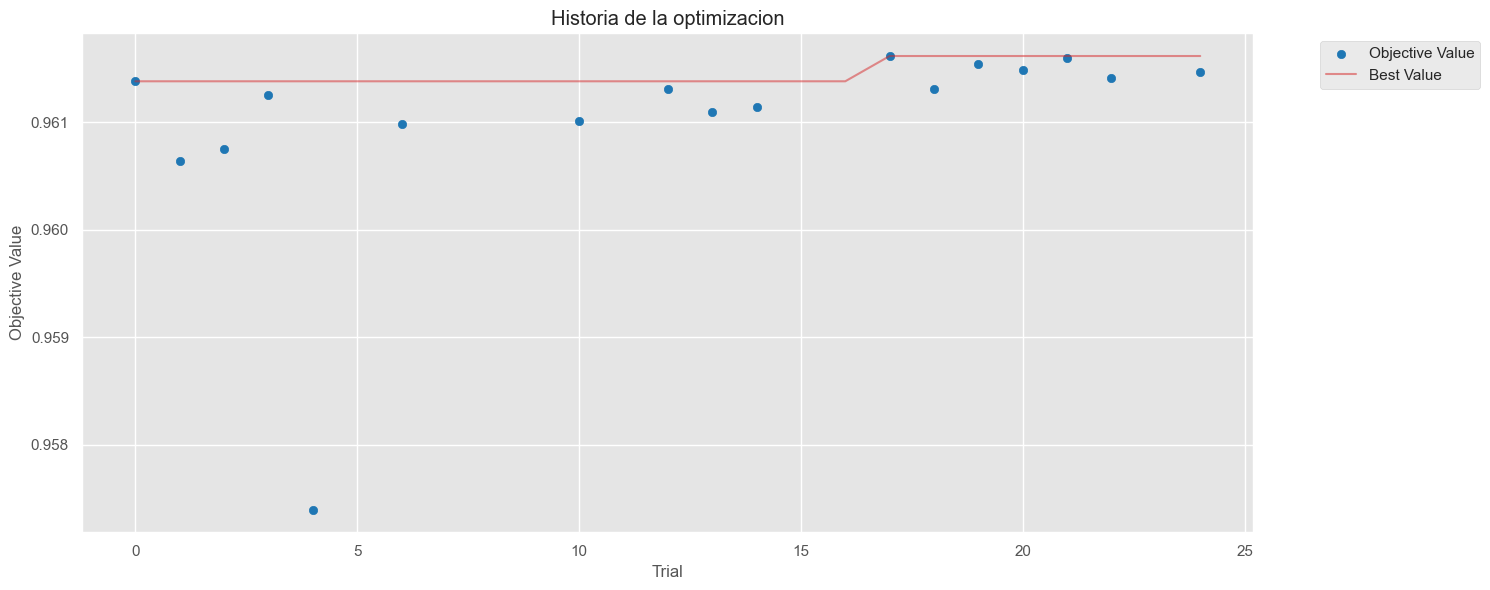

<Figure size 1100x500 with 0 Axes>

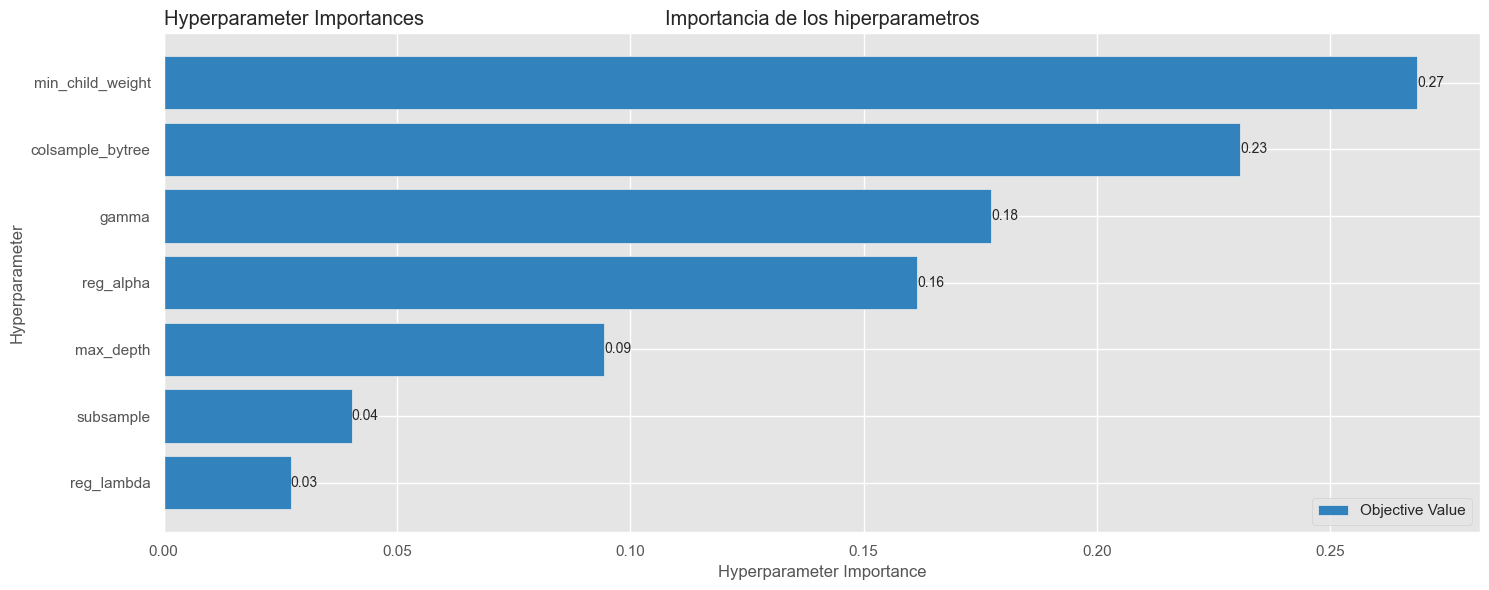

Top 5 configuraciones:
 number  value    state  params_colsample_bytree  params_gamma  params_max_depth  params_min_child_weight  params_reg_alpha  params_reg_lambda  params_subsample
     17 0.9616 COMPLETE                   0.6757        0.5520                 5                       13            0.0010             0.4489            0.8469
     21 0.9616 COMPLETE                   0.6611        1.3110                 5                       13            0.0011             0.0987            0.8344
     19 0.9615 COMPLETE                   0.6700        0.6002                 5                       14            0.0033             0.0234            0.8501
     20 0.9615 COMPLETE                   0.6658        1.2238                 5                       13            0.0010             0.3537            0.8411
     24 0.9615 COMPLETE                   0.6136        1.3324                 5                       12            0.0010             0.0904            0.8155


In [5]:
# Las funciones de optuna.visualization.matplotlib NO aceptan un parametro `ax`:
# dibujan sobre los ejes actuales, asi que hay que crear la figura antes de llamarlas.
plt.figure(figsize=(11, 5))
ax = ovm.plot_optimization_history(study)
ax.set_title("Historia de la optimizacion")
plt.tight_layout()
plt.show()

try:
    plt.figure(figsize=(11, 5))
    ax = ovm.plot_param_importances(study)
    ax.set_title("Importancia de los hiperparametros")
    plt.tight_layout()
    plt.show()
except Exception as e:
    plt.close()
    print(f"Importancias no disponibles: {e}")

df_trials = study.trials_dataframe(attrs=("number", "value", "state", "params"))
print("Top 5 configuraciones:")
print(df_trials.sort_values("value", ascending=False).head(5).round(4).to_string(index=False))

## 5. Modelo Final — CV Completa

Los mejores hiperparámetros se llevan al régimen del notebook 3 para que la comparación sea justa:
**train completo, 5 folds, `learning_rate=0,05` y `early_stopping_rounds=100`**. Lo único que cambia
respecto de aquel notebook son los hiperparámetros encontrados.

In [6]:
PARAMS_FINAL = dict(
    **BASE_PARAMS,
    **study.best_params,
    n_estimators=5000,
    learning_rate=0.05,
    early_stopping_rounds=100,
)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof      = np.zeros(len(X), dtype=np.float32)
test_sum = np.zeros(len(X_test), dtype=np.float32)
aucs, iters, modelos = [], [], []

print(f"{'='*62}")
print("CROSS-VALIDATION FINAL — XGBoost tuneado")
print(f"{'='*62}")
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    modelo = XGBClassifier(**PARAMS_FINAL)
    modelo.fit(X.iloc[tr_idx], y[tr_idx],
               eval_set=[(X.iloc[val_idx], y[val_idx])], verbose=False)
    p_val         = modelo.predict_proba(X.iloc[val_idx])[:, 1]
    oof[val_idx]  = p_val
    test_sum     += modelo.predict_proba(X_test)[:, 1]
    aucs.append(roc_auc_score(y[val_idx], p_val))
    iters.append(modelo.best_iteration)
    modelos.append(modelo)
    print(f"  Fold {fold}: AUC = {aucs[-1]:.5f}  |  best_iteration = {iters[-1]}")

test_tuned = test_sum / N_FOLDS
cv_mean    = np.mean(aucs)
print(f"{'='*62}")
print(f"  Media: {cv_mean:.5f} +/- {np.std(aucs):.5f}")
print(f"  AUC out-of-fold: {roc_auc_score(y, oof):.5f}")
print(f"  Arboles usados (media): {np.mean(iters):.0f} de 5000")
print(f"{'='*62}")

CROSS-VALIDATION FINAL — XGBoost tuneado
  Fold 1: AUC = 0.96437  |  best_iteration = 3582
  Fold 2: AUC = 0.96519  |  best_iteration = 3876
  Fold 3: AUC = 0.96512  |  best_iteration = 3358
  Fold 4: AUC = 0.96600  |  best_iteration = 3817
  Fold 5: AUC = 0.96469  |  best_iteration = 2916
  Media: 0.96507 +/- 0.00055
  AUC out-of-fold: 0.96507
  Arboles usados (media): 3510 de 5000


## 6. Comparación con el XGBoost sin Tunear

In [7]:
AUC_XGB_BASE = 0.96478   # 3_xgboost.ipynb
AUC_LGBM     = 0.96422   # 4_lightgbm.ipynb
LB_XGB_BASE  = 0.96634   # score publico de 3_xgboost

comparativa = pd.DataFrame({
    "modelo": ["XGBoost sin tunear", "LightGBM", "XGBoost + Optuna"],
    "CV AUC": [AUC_XGB_BASE, AUC_LGBM, cv_mean],
})
comparativa["delta vs base"] = (comparativa["CV AUC"] - AUC_XGB_BASE).round(5)

print(f"{'='*62}")
print("COMPARATIVA")
print(f"{'='*62}")
print(comparativa.round(5).to_string(index=False))
print(f"{'='*62}")
print(f"  Desvio entre folds del modelo tuneado: {np.std(aucs):.5f}")
if cv_mean - AUC_XGB_BASE < np.std(aucs):
    print("  ATENCION: la mejora es menor al desvio entre folds -> puede ser ruido.")

COMPARATIVA
            modelo  CV AUC  delta vs base
XGBoost sin tunear 0.96478        0.00000
          LightGBM 0.96422       -0.00056
  XGBoost + Optuna 0.96507        0.00029
  Desvio entre folds del modelo tuneado: 0.00055
  ATENCION: la mejora es menor al desvio entre folds -> puede ser ruido.


## 7. Ensamble con los Modelos Previos

El modelo tuneado es una variante del mismo algoritmo, así que se espera una correlación de rangos
altísima con el XGBoost base — probablemente por encima del 0,9955 que ya vimos entre XGBoost y
LightGBM. Se mide igual, por completitud.

In [8]:
oof_xgb  = np.load("../models/3_xgboost_oof.npy")
test_xgb = np.load("../models/3_xgboost_test.npy")
oof_lgb  = np.load("../models/4_lightgbm_oof.npy")
test_lgb = np.load("../models/4_lightgbm_test.npy")

r_tuned = rankdata(oof) / len(oof)
r_xgb   = rankdata(oof_xgb) / len(oof_xgb)
r_lgb   = rankdata(oof_lgb) / len(oof_lgb)

print(f"Correlacion de rangos tuneado vs XGBoost base: {np.corrcoef(r_tuned, r_xgb)[0,1]:.4f}")
print(f"Correlacion de rangos tuneado vs LightGBM:     {np.corrcoef(r_tuned, r_lgb)[0,1]:.4f}")

mejor = {"auc": 0.0}
for w_t in np.round(np.arange(0, 1.01, 0.05), 2):
    for w_lgb in np.round(np.arange(0, 1.01 - w_t, 0.05), 2):
        w_xgb = round(1 - w_t - w_lgb, 2)
        auc = roc_auc_score(y, w_t * r_tuned + w_lgb * r_lgb + w_xgb * r_xgb)
        if auc > mejor["auc"]:
            mejor = {"auc": auc, "w_tuned": w_t, "w_lgb": w_lgb, "w_xgb": w_xgb}

mejor_individual = max(cv_mean, AUC_XGB_BASE, AUC_LGBM)
print(f"\nMejor ensamble -> tuneado: {mejor['w_tuned']:.2f} | lightgbm: {mejor['w_lgb']:.2f} | "
      f"xgb base: {mejor['w_xgb']:.2f}")
print(f"  AUC del ensamble:        {mejor['auc']:.5f}")
print(f"  Mejor modelo individual: {mejor_individual:.5f}")
print(f"  Ganancia:                {mejor['auc'] - mejor_individual:+.5f}")

Correlacion de rangos tuneado vs XGBoost base: 0.9979
Correlacion de rangos tuneado vs LightGBM:     0.9952

Mejor ensamble -> tuneado: 0.65 | lightgbm: 0.20 | xgb base: 0.15
  AUC del ensamble:        0.96519
  Mejor modelo individual: 0.96507
  Ganancia:                +0.00011


## 8. Predicción sobre Test y Submission

In [9]:
submission = pd.DataFrame({"id": test["id"], TARGET: test_tuned})
submission.to_csv("../submissions/6_xgboost_optuna_submission.csv", index=False)
np.save("../models/6_xgboost_optuna_oof.npy",  oof)
np.save("../models/6_xgboost_optuna_test.npy", test_tuned)

sample = pd.read_csv("../data/sample_submission.csv")
assert list(submission.columns) == list(sample.columns), "columnas no coinciden"
assert len(submission) == len(sample), "cantidad de filas no coincide"
assert (submission["id"].values == sample["id"].values).all(), "ids no alineados"
assert submission[TARGET].between(0, 1).all(), "valores fuera de [0, 1]"
assert submission[TARGET].notna().all(), "hay nulos"
print(f"Submission escrita: ../submissions/6_xgboost_optuna_submission.csv ({len(submission):,} filas)")
print(f"  proba media: {test_tuned.mean():.4f}  (tasa base train: {y.mean():.4f})")
print("  Chequeos OK.")

if mejor["auc"] > mejor_individual:
    mezcla = (mejor["w_tuned"] * (rankdata(test_tuned) / len(test_tuned)) +
              mejor["w_lgb"]   * (rankdata(test_lgb)   / len(test_lgb)) +
              mejor["w_xgb"]   * (rankdata(test_xgb)   / len(test_xgb)))
    pd.DataFrame({"id": test["id"], TARGET: mezcla}).to_csv(
        "../submissions/6_ensamble_submission.csv", index=False)
    print("\nEnsamble escrito: ../submissions/6_ensamble_submission.csv")
else:
    print("\nNo se escribe ensamble: no supera al mejor modelo individual.")

Submission escrita: ../submissions/6_xgboost_optuna_submission.csv (296,302 filas)
  proba media: 0.7095  (tasa base train: 0.7094)
  Chequeos OK.

Ensamble escrito: ../submissions/6_ensamble_submission.csv


## 9. Envío a Kaggle vía API

`FILE` elige solo: manda el ensamble si ganó en OOF, y si no el modelo tuneado. Ojo con no gastar el
envío si la mejora sobre el 0,96634 que ya está en el leaderboard resulta menor al desvío entre folds.

In [10]:
usar_ensamble = mejor["auc"] > mejor_individual

COMPETITION = "playground-series-s6e8"
FILE = ("../submissions/6_ensamble_submission.csv" if usar_ensamble
        else "../submissions/6_xgboost_optuna_submission.csv")
MSG  = (f"Ensamble tuneado+lgbm+xgb - OOF AUC={mejor['auc']:.5f}" if usar_ensamble
        else f"XGBoost + Optuna ({N_TRIALS} trials) - CV AUC={cv_mean:.5f}")

print(f"Se enviaria: {FILE}")
print(f"Mensaje:     {MSG}")
print(f"Referencia en el leaderboard: {LB_XGB_BASE} (XGBoost sin tunear)")

Se enviaria: ../submissions/6_ensamble_submission.csv
Mensaje:     Ensamble tuneado+lgbm+xgb - OOF AUC=0.96519
Referencia en el leaderboard: 0.96634 (XGBoost sin tunear)


In [11]:
!kaggle competitions submit -c {COMPETITION} -f "{FILE}" -m "{MSG}"

Successfully submitted to Predicting Smartphone Addiction



  0%|          | 0.00/7.71M [00:00<?, ?B/s]
  0%|          | 16.0k/7.71M [00:00<01:17, 104kB/s]
  7%|▋         | 560k/7.71M [00:00<00:03, 2.46MB/s]
 11%|█         | 832k/7.71M [00:01<00:09, 752kB/s] 
 61%|██████    | 4.72M/7.71M [00:01<00:00, 6.20MB/s]
 81%|████████▏ | 6.27M/7.71M [00:01<00:00, 7.38MB/s]
 99%|█████████▉| 7.66M/7.71M [00:01<00:00, 7.46MB/s]
100%|██████████| 7.71M/7.71M [00:01<00:00, 4.04MB/s]


In [12]:
!kaggle competitions submissions -c playground-series-s6e8

     ref  fileName                         date                        description                                                      status                     publicScore  privateScore  
--------  -------------------------------  --------------------------  ---------------------------------------------------------------  -------------------------  -----------  ------------  
55587821  6_ensamble_submission.csv        2026-08-17 23:56:17.433000  Ensamble tuneado+lgbm+xgb - OOF AUC=0.96519                      SubmissionStatus.PENDING                              
55537898  5_red_neuronal_submission.csv    2026-08-15 23:32:30.953000  Red neuronal Keras - experimento de diversidad - CV AUC=0.94092  SubmissionStatus.COMPLETE  0.94270                    
55537897  5_red_neuronal_submission.csv    2026-08-15 23:32:24.837000  Red neuronal Keras - experimento de diversidad - CV AUC=0.94092  SubmissionStatus.COMPLETE  0.94270                    
55536391  4_lgbm_xgb_blend_submission.csv  20

## 10. Conclusiones

- **CV AUC = 0,96507 ± 0,00055**, contra 0,96478 del modelo sin tunear: **+0,00029**.

  > **Corrección importante.** La celda de arriba imprime "la mejora es menor al desvío entre folds ->
  > puede ser ruido", y esa alerta —que yo mismo programé— **usa el estadístico equivocado**. El desvío
  > entre folds mide qué tan distintos son los folds entre sí, no qué tan distintos son los modelos.
  > Como ambos modelos se evaluaron sobre **los mismos folds**, esa varianza compartida se cancela al
  > restar. El análisis pareado de `7_ruido_y_significancia.ipynb` da un sigma de la diferencia de
  > **0,00003** (nueve veces menor que el absoluto), lo que deja la mejora en **z = 11,1**; y el
  > modelo tuneado gana en **5 de 5 folds**, con t pareado de 8,33. **La mejora es real.**
  >
  > Vale además la referencia externa: en el foro de la competencia se midió que la brecha entre el
  > puesto 1 y el 50 del leaderboard es de 0,00031 AUC. Este +0,00029 es exactamente de ese orden.
  > En esta competencia, "diminuto en términos absolutos" no es lo mismo que "irrelevante".
- **La superficie de hiperparámetros es llamativamente plana.** Los 25 trials se movieron entre
  0,95720 y 0,96162 — apenas 0,0044 de rango total. Y el **trial 0**, la primera configuración
  muestreada al azar, ya daba 0,96138: toda la búsqueda ganó **+0,00024** sobre esa primera tirada.
  XGBoost es notablemente insensible a sus hiperparámetros en este dataset.
- **TPE igualmente convergió a una región estrecha y coherente**: los cinco mejores trials comparten
  `max_depth=5`, `min_child_weight` entre 12 y 14, `subsample` ~0,82-0,85 y `colsample_bytree`
  ~0,61-0,68. Encontró un óptimo real; lo que pasa es que el óptimo es chato.
- **El tuning cambió la forma del modelo, no su resultado.** La configuración ganadora usa árboles más
  débiles y regularizados que la del notebook 3 (`max_depth` 5 contra 6, `min_child_weight` 13 contra
  5, `gamma` 0,55 contra 0) y lo compensa con **3510 árboles contra 2215** (+58 %). Llega al mismo
  lugar por otro camino y gastando más cómputo.
- **El pruner hizo su trabajo**: descartó 8 de 25 trials. Con `trial.report()` por fold no queda
  decorativo, a diferencia del notebook de Optuna del Episodio 1.
- **Correlación de rangos con el XGBoost base: 0,9979** — la más alta del episodio, como correspondía
  entre dos configuraciones del mismo algoritmo. El ensamble de las tres variantes de árboles
  (0,65 tuneado / 0,20 LightGBM / 0,15 XGBoost base) da 0,96519: **+0,00011** sobre el mejor
  individual. Acá sí conviene desconfiar, pero **por otro motivo que el ruido**: los tres pesos se
  eligieron maximizando ese mismo OOF, así que la ganancia está **sesgada por selección**. Es la
  diferencia con el caso del tuning, donde los hiperparámetros se eligieron sobre una submuestra y un
  esquema de folds **distintos** de los usados para evaluar.
- **El presupuesto se estimó mal**: la búsqueda se planificó en 50-60 min y tardó **99**. La causa es
  que los recortes (submuestra, 3 folds, `lr` duplicado) se calcularon sobre el costo del notebook 3,
  pero varias configuraciones exploradas resultaron más caras que aquella — árboles más chicos
  requieren muchos más de ellos antes de que corte el early stopping.

### Cierre del episodio

Se probaron cuatro vías para superar el 0,96478 del notebook 3:

| Vía | Resultado | Veredicto (con el test pareado) |
|---|---|---|
| Otro algoritmo de árboles (LightGBM) | 0,96422 | **Peor**, y de forma real: z = 14,6 |
| Otra clase de modelo (red neuronal) | 0,94092 | −0,024, y peso 0 en el ensamble |
| Foundation model tabular (TabICL) | ~0,94 proyectado | El más diverso (0,9515) y aun así no aporta |
| **Tuning de hiperparámetros** | **0,96507** | **Mejor: +0,00029, z = 11,1, gana 5/5 folds** |

La conclusión correcta no es que estemos en una meseta donde nada se mueve, sino algo más matizado:
**las diferencias entre modelos de árboles son diminutas pero medibles**, y las diferencias contra
otras familias de modelos son enormes. El tuning fue la única vía que mejoró, y su mejora es del mismo
orden que la brecha entre los puestos 1 y 50 del leaderboard.

**El ruido de entrenamiento también quedó descartado.** `7_ruido_y_significancia.ipynb` reentrenó
ambas configuraciones con tres semillas del booster: el tuneado ganó **3 de 3**, con diferencias de
+0,00036, +0,00041 y +0,00043. El desvío entre semillas es de 0,00002-0,00005, **diez veces menor que
la ventaja**. Sumado a los 5/5 folds y a los 200/200 resamples del bootstrap pareado, la mejora del
tuning es sólida por tres vías independientes.

**Una consecuencia práctica sobre qué enviar.** La celda de envío de este notebook eligió el ensamble
porque ganaba en OOF, pero ahora sabemos que esa ganancia estaba sesgada por selección, mientras que
la del modelo tuneado es genuina. Para el envío final conviene
`6_xgboost_optuna_submission.csv` —el modelo tuneado solo— antes que el ensamble.